In [1]:
# Test to change the grid from (lon, lat) coordinates to (x,y)
# and vice-versa

import xarray as xr
import shapely
import dask.array as da
import numpy as np
import geopandas as gpd
from pyproj import CRS, Transformer
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# CRSs
WGS84 = CRS('epsg:4326')  # WGS84 : (lon, lat)
ETRS89UTM = CRS('epsg:25834') # ETRS89 / UTM zone 34N : (x, y)

infol = '/scratch/project_2018610/opendrift_outputs/'
outfol = '/scratch/project_2018610/connectivity/rasters/'

# set opendrift output file name
#ncfile = 'test_seeding_2500_every_third_day_region_1_2017_test.nc'
ncfile = 'test_seeding_2500_every_third_day_region_1_2018_test.nc'

# set raster file name, netcdf
raster_nc = ncfile.replace('.nc','_uniqsum_raster_metres.nc')
# set raster file name, tif
raster_tif = raster_nc.replace('.nc','.tif')


In [2]:
# create the transformer
transformer_lonlatTo2dxy = Transformer.from_crs(WGS84, ETRS89UTM, always_xy=True)
transformer_2dxyTolonlat = Transformer.from_crs(ETRS89UTM, WGS84, always_xy=True)


#lon, lat = np.meshgrid(lon, lat)
#x, y = transformer_lonlatTo2dxy.transform(lon, lat)

In [3]:
# load opendrift output
ds = xr.open_dataset(infol+ncfile, chunks={})
ds = ds.chunk({'trajectory': 100})

# extract lon and lat and flatten
lon = ds.lon.data.reshape(-1)
lat = ds.lat.data.reshape(-1)

In [4]:
# x, y = transformer_lonlatTo2dxy.transform(lon, lat)

In [54]:
# vectorized Shapely point constructor
def make_points(lon_arr, lat_arr):
    return shapely.points(lon_arr, lat_arr)

# apply with dask
points = da.map_blocks(
    make_points,
    lon, lat,
    dtype=object
)

In [55]:
# extract and flatten needed variables from opendrift output
status = ds.status.data.reshape(-1)
age = ds.age_seconds.data.reshape(-1)/60./60.  # seconds --> hours
z = ds.z.data.reshape(-1)
origin = ds.origin_marker.data.reshape(-1)

# trajectory and time indices
traj_index = np.repeat(ds.trajectory.values, ds.time.size)+1
time_index = np.tile(ds.time.values, ds.trajectory.size)

In [56]:
# compute geometry and and other variables for geodataframe
geom = points.compute()
status_v = status.compute()
age_v = age.compute()
z_v = z.compute()
origin_v = origin.compute()
traj_v = traj_index
time_v = time_index

In [57]:
# build geodataframe
coords = gpd.GeoDataFrame(
    {
        "traj": traj_v,
        "time": time_v,
        "status": status_v,
        "age_hours": age_v,
        "z": z_v,
        "origin_marker": origin_v,
    },
    geometry=geom,
    crs="EPSG:4326"
)

In [58]:
coords

,traj,time,status,age_hours,z,origin_marker,geometry
0,1,2018-06-01 00:00:00,0.0,0.0,-5.0,0.0,POINT (19.3341 60.60668)
1,1,2018-06-01 01:00:00,0.0,1.0,-5.0,0.0,POINT (19.33584 60.60675)
2,1,2018-06-01 02:00:00,0.0,2.0,-5.0,0.0,POINT (19.33748 60.60684)
3,1,2018-06-01 03:00:00,0.0,3.0,-5.0,0.0,POINT (19.33903 60.60696)
4,1,2018-06-01 04:00:00,0.0,4.0,-5.0,0.0,POINT (19.34048 60.60709)
...,...,...,...,...,...,...,...
1627495,7500,2018-06-09 20:00:00,0.0,68.0,-5.0,2.0,POINT (20.4912 60.92561)
1627496,7500,2018-06-09 21:00:00,0.0,69.0,-5.0,2.0,POINT (20.49377 60.92617)
1627497,7500,2018-06-09 22:00:00,0.0,70.0,-5.0,2.0,POINT (20.49651 60.92671)
1627498,7500,2018-06-09 23:00:00,0.0,71.0,-5.0,2.0,POINT (20.49942 60.92723)


In [59]:
coords = coords.to_crs("EPSG:25834")

In [60]:
coords

,traj,time,status,age_hours,z,origin_marker,geometry
0,1,2018-06-01 00:00:00,0.0,0.0,-5.0,0.0,POINT (408793.283 6720134.022)
1,1,2018-06-01 01:00:00,0.0,1.0,-5.0,0.0,POINT (408888.71 6720139.681)
2,1,2018-06-01 02:00:00,0.0,2.0,-5.0,0.0,POINT (408978.865 6720147.602)
3,1,2018-06-01 03:00:00,0.0,3.0,-5.0,0.0,POINT (409063.759 6720158.207)
4,1,2018-06-01 04:00:00,0.0,4.0,-5.0,0.0,POINT (409143.371 6720170.649)
...,...,...,...,...,...,...,...
1627495,7500,2018-06-09 20:00:00,0.0,68.0,-5.0,2.0,POINT (472416.749 6754608.071)
1627496,7500,2018-06-09 21:00:00,0.0,69.0,-5.0,2.0,POINT (472556.82 6754669.449)
1627497,7500,2018-06-09 22:00:00,0.0,70.0,-5.0,2.0,POINT (472705.97 6754728.637)
1627498,7500,2018-06-09 23:00:00,0.0,71.0,-5.0,2.0,POINT (472863.987 6754785.215)


In [66]:
# read grid file (grid must be stored as polygons)
gridfile = '/projappl/project_2018610/data/grids/test_grid_1000m.gpkg'
grid = gpd.read_file(gridfile, layer="test_grid_1000m")

In [67]:
grid

,gridid,c_coords,geometry
0,1,POINT (279349 6638061),"POLYGON ((279848.567 6637561.125, 278848.567 6..."
1,2,POINT (279349 6639061),"POLYGON ((279848.567 6638561.125, 278848.567 6..."
2,3,POINT (279349 6640061),"POLYGON ((279848.567 6639561.125, 278848.567 6..."
3,4,POINT (279349 6641061),"POLYGON ((279848.567 6640561.125, 278848.567 6..."
4,5,POINT (279349 6642061),"POLYGON ((279848.567 6641561.125, 278848.567 6..."
...,...,...,...
114907,114908,POINT (566349 7032061),"POLYGON ((566848.567 7031561.125, 565848.567 7..."
114908,114909,POINT (566349 7033061),"POLYGON ((566848.567 7032561.125, 565848.567 7..."
114909,114910,POINT (566349 7034061),"POLYGON ((566848.567 7033561.125, 565848.567 7..."
114910,114911,POINT (566349 7035061),"POLYGON ((566848.567 7034561.125, 565848.567 7..."


In [68]:
# spatial join on grid and trajectory dataframes
df = gpd.sjoin(grid, coords)
# count unique trajectories passing each grid cell
nunique = df.groupby('gridid')['traj'].nunique()


#testing if I can use a 'probability'
#nunique = df.groupby('gridid')['traj'].nunique()/df['traj'].max()

# merge the resulting geoseries with original grid dataframe
unique = grid.merge(nunique, how='left', left_on='gridid', right_index=True)
# rename column
unique.rename(columns = {'traj':'N_count'}, inplace = True)

In [69]:
unique

,gridid,c_coords,geometry,N_count
0,1,POINT (279349 6638061),"POLYGON ((279848.567 6637561.125, 278848.567 6...",NaN
1,2,POINT (279349 6639061),"POLYGON ((279848.567 6638561.125, 278848.567 6...",NaN
2,3,POINT (279349 6640061),"POLYGON ((279848.567 6639561.125, 278848.567 6...",NaN
3,4,POINT (279349 6641061),"POLYGON ((279848.567 6640561.125, 278848.567 6...",NaN
4,5,POINT (279349 6642061),"POLYGON ((279848.567 6641561.125, 278848.567 6...",NaN
...,...,...,...,...
114907,114908,POINT (566349 7032061),"POLYGON ((566848.567 7031561.125, 565848.567 7...",NaN
114908,114909,POINT (566349 7033061),"POLYGON ((566848.567 7032561.125, 565848.567 7...",NaN
114909,114910,POINT (566349 7034061),"POLYGON ((566848.567 7033561.125, 565848.567 7...",NaN
114910,114911,POINT (566349 7035061),"POLYGON ((566848.567 7034561.125, 565848.567 7...",NaN


In [72]:
# prepare output to be saved
# set nans to zero:
output = unique.fillna(0)
# change grid cell center coordinates to geometry
# (this part depends on the grid file, and the following works with the test grid files Elina made)
output['geometry'] = output['c_coords'].apply(shapely.wkt.loads)

# saving to netcdf - we probably need only this
# get center coordinates to be used as indices in xarray
output['x'] = output.geometry.x
output['y'] = output.geometry.y
# convert to xarray
da = output.set_index(['y', 'x']).N_count.to_xarray()
print('...check if nans in output: {}'.format(np.isnan(da.data).any()))
# save to netcdf
print('...saving to '+outfol+raster_nc)
da.to_netcdf(outfol+raster_nc)

...check if nans in output: False
...saving to /scratch/project_2018610/connectivity/rasters/test_seeding_2500_every_third_day_region_1_2018_test_uniqsum_raster_metres.nc


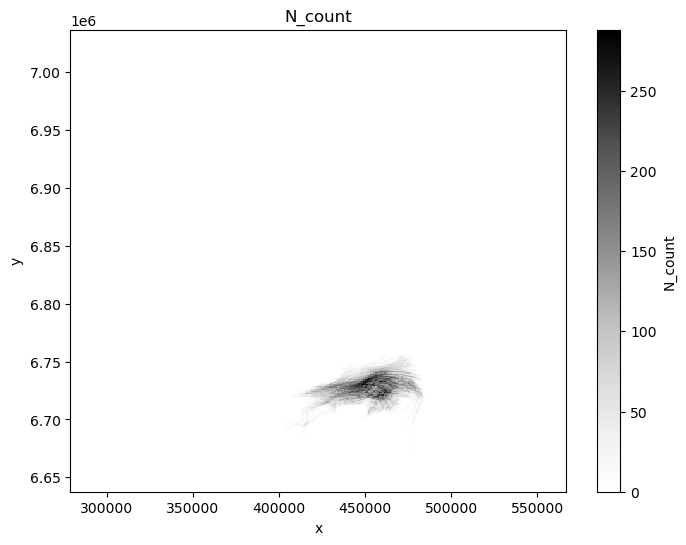

In [5]:
d = xr.open_dataset(outfol+raster_nc)

# extract the variable
da = d["N_count"]

fig, ax = plt.subplots(figsize=(8, 6))

# plot as 2D colored map
da.plot(
    ax=ax,
    cmap="Greys",   # light -> dark grey
    #robust=True    # optional, improves contrast
)

ax.set_title("N_count")
plt.show()

In [6]:
d

<xarray.Dataset> Size: 925kB
Dimensions:  (y: 399, x: 288)
Coordinates:
  * y        (y) float64 3kB 6.638e+06 6.639e+06 ... 7.035e+06 7.036e+06
  * x        (x) float64 2kB 2.793e+05 2.803e+05 ... 5.653e+05 5.663e+05
Data variables:
    N_count  (y, x) float64 919kB ...

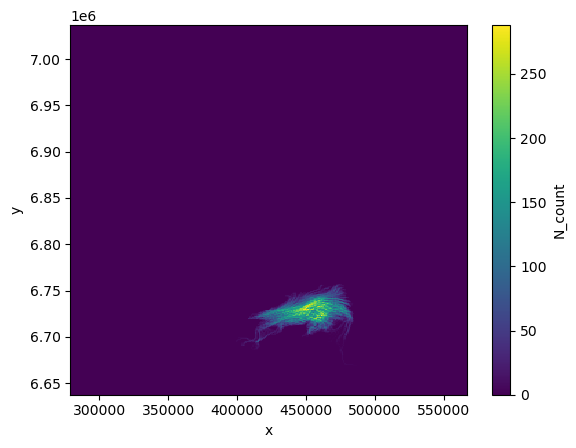

In [7]:
d.N_count.plot()

In [17]:
X, Y = np.meshgrid(d.x.values, d.y.values)

lon, lat = transformer_2dxyTolonlat.transform(X, Y)

In [18]:
lon

array([[17.06377261, 17.08156307, 17.0993542 , ..., 22.1493784 ,
        22.16723575, 22.1850929 ],
       [17.06271408, 17.0805093 , 17.09830517, ..., 22.14968838,
        22.16755055, 22.18541251],
       [17.06165489, 17.07945486, 17.09725549, ..., 22.14999856,
        22.16786554, 22.18573232],
       ...,
       [16.58577626, 16.60571103, 16.62564676, ..., 22.28943242,
        22.30946429, 22.32949589],
       [16.58440022, 16.60434115, 16.62428305, ..., 22.28983583,
        22.30987397, 22.32991182],
       [16.58302321, 16.60297032, 16.62291838, ..., 22.29023953,
        22.31028394, 22.33032806]], shape=(399, 288))

In [21]:
d["x"] = (("y", "x"), lon)
d["y"] = (("y", "x"), lat)

In [22]:
d

<xarray.Dataset> Size: 5MB
Dimensions:  (y: 399, x: 288)
Coordinates:
    y        (y, x) float64 919kB 59.82 59.82 59.82 59.82 ... 63.45 63.45 63.45
    x        (y, x) float64 919kB 17.06 17.08 17.1 17.12 ... 22.29 22.31 22.33
Data variables:
    N_count  (y, x) float64 919kB ...
    lon      (y, x) float64 919kB 17.06 17.08 17.1 17.12 ... 22.29 22.31 22.33
    lat      (y, x) float64 919kB 59.82 59.82 59.82 59.82 ... 63.45 63.45 63.45

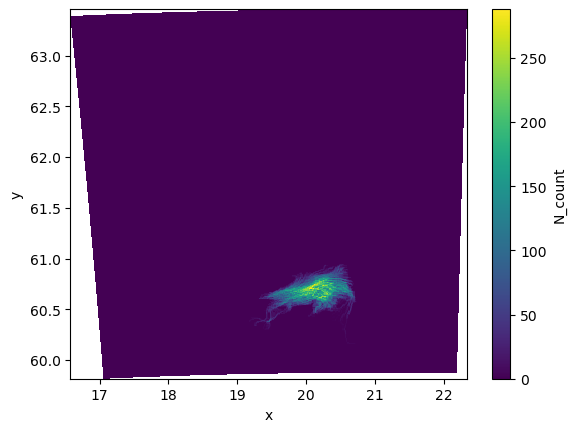

In [23]:
d.N_count.plot()